In [5]:
from google.colab import files
print("📤 Upload Ethiopia CSV file")
uploaded = files.upload()

📤 Upload Ethiopia CSV file


Saving ethiopia.csv to ethiopia (1).csv


In [6]:
from google.colab import files
print("📤 Upload Kenya CSV file")
uploaded = files.upload()

📤 Upload Kenya CSV file


Saving kenya.csv to kenya (1).csv


In [7]:
from google.colab import files
print("📤 Upload Nigeria CSV file")
uploaded = files.upload()

📤 Upload Nigeria CSV file


Saving nigeria.csv to nigeria.csv


In [8]:
from google.colab import files
print("📤 Upload Sudan CSV file")
uploaded = files.upload()

📤 Upload Sudan CSV file


Saving sudan.csv to sudan.csv


In [9]:
from google.colab import files
print("📤 Upload Tanzania CSV file")
uploaded = files.upload()

📤 Upload Tanzania CSV file


Saving tanzania.csv to tanzania.csv


✅ Libraries loaded

LOADING CLIMATE DATA FOR 5 AFRICAN NATIONS

📁 Found CSV files: ['kenya (1).csv', 'sudan.csv', 'nigeria.csv', 'ethiopia (1).csv', 'kenya.csv', 'tanzania.csv', 'ethiopia.csv']
✅ Loaded Kenya (1): 4108 rows
✅ Loaded Sudan: 4108 rows
✅ Loaded Nigeria: 4108 rows
✅ Loaded Ethiopia (1): 4108 rows
✅ Loaded Kenya: 4108 rows
✅ Loaded Tanzania: 4108 rows
✅ Loaded Ethiopia: 4108 rows

📊 Combined dataset: 28756 rows from 7 countries
   Countries: ['Kenya (1)', 'Sudan', 'Nigeria', 'Ethiopia (1)', 'Kenya', 'Tanzania', 'Ethiopia']

📊 TEMPERATURE TREND COMPARISON


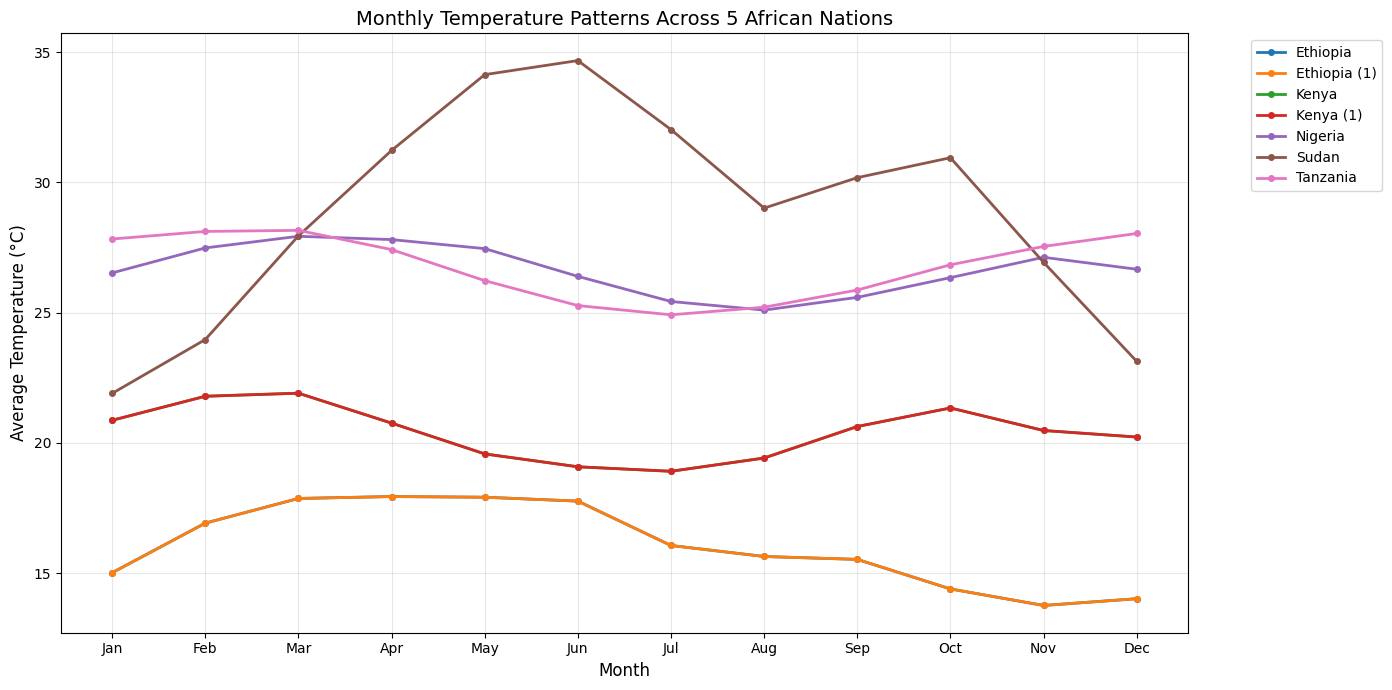


📊 TEMPERATURE SUMMARY TABLE (Mean, Median, Std Dev)
------------------------------------------------------------
              Mean (°C)  Median (°C)  Std Dev (°C)
Country                                           
Sudan              28.8         29.2           4.7
Tanzania           26.8         27.0           1.3
Nigeria            26.7         26.8           1.1
Kenya              20.4         20.4           1.4
Kenya (1)          20.4         20.4           1.4
Ethiopia (1)       16.1         16.0           1.9
Ethiopia           16.1         16.0           1.9

🌧️ PRECIPITATION VARIABILITY COMPARISON


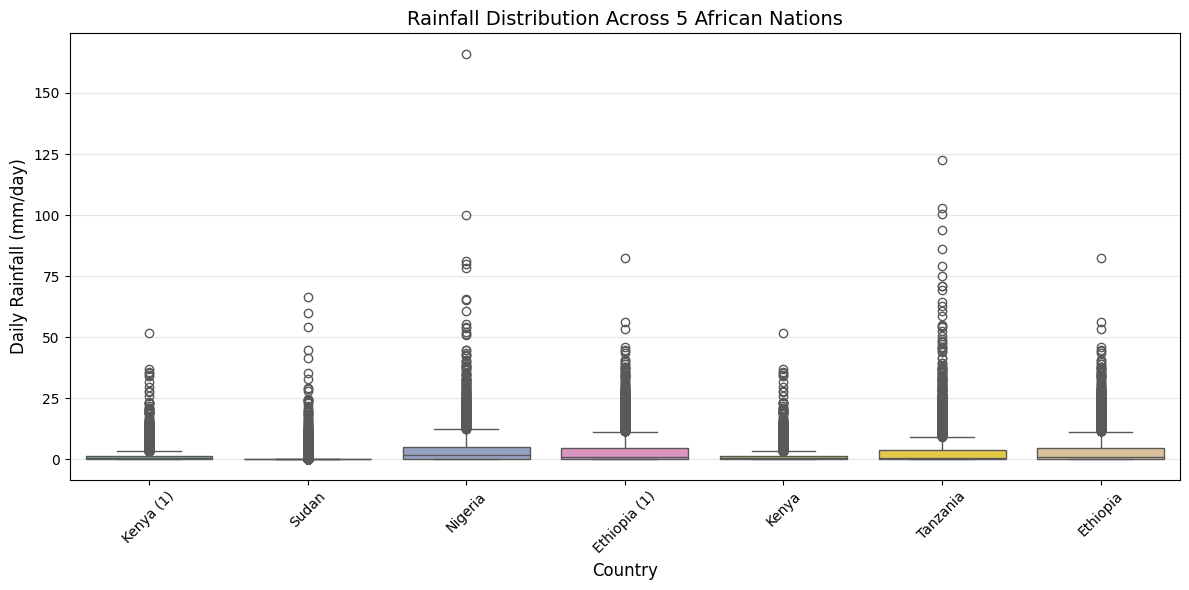


📊 RAINFALL SUMMARY TABLE (Mean, Median, Std Dev)
------------------------------------------------------------
              Mean (mm/day)  Median (mm/day)  Std Dev (mm/day)
Country                                                       
Nigeria                4.21             1.84              7.27
Tanzania               3.74             0.64              8.00
Ethiopia               3.63             0.82              6.29
Ethiopia (1)           3.63             0.82              6.29
Kenya                  1.47             0.38              3.18
Kenya (1)              1.47             0.38              3.18
Sudan                  0.64             0.00              3.06

🔥 EXTREME EVENT FREQUENCY ANALYSIS


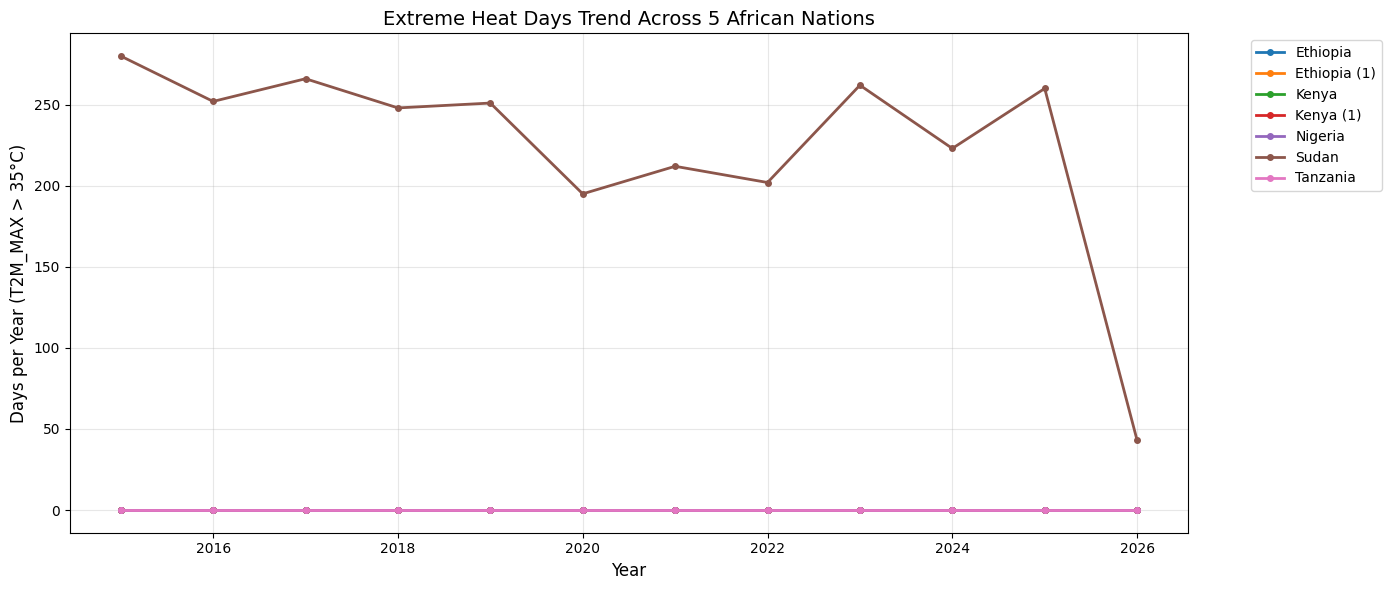


📊 Average Extreme Heat Days per Year (T2M_MAX > 35°C):
Country
Sudan           0.7
Ethiopia (1)    0.0
Ethiopia        0.0
Kenya           0.0
Kenya (1)       0.0
Nigeria         0.0
Tanzania        0.0
Name: Extreme_Heat, dtype: float64


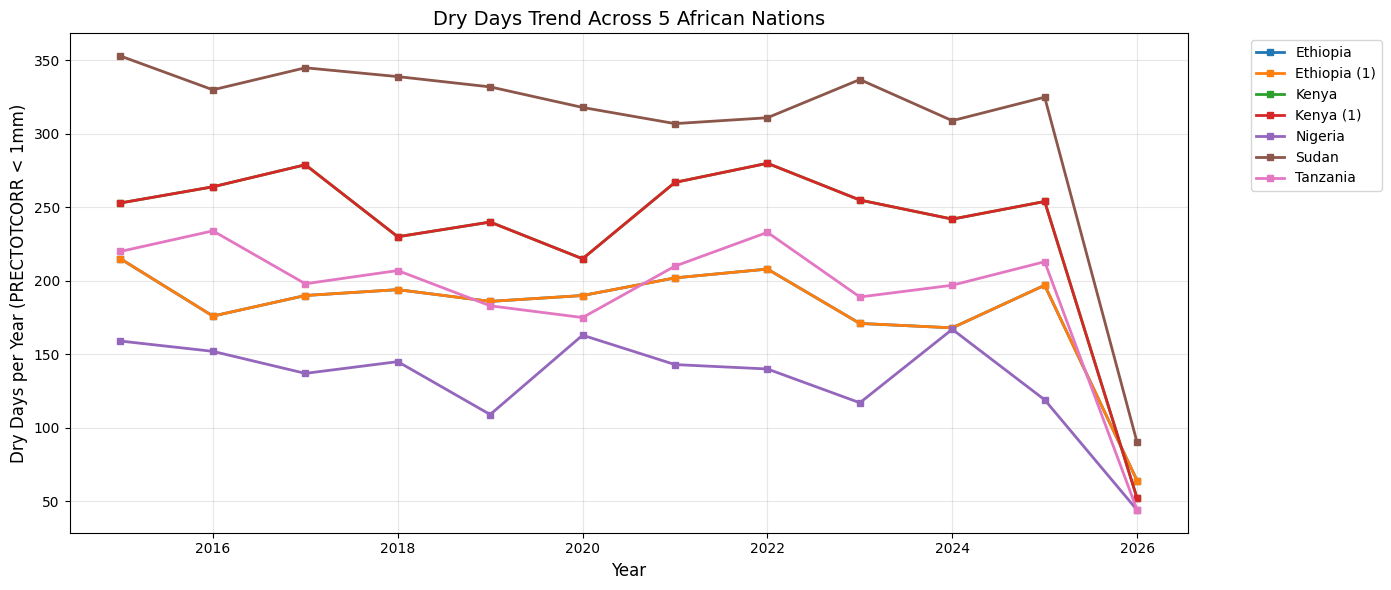


📊 Average Dry Days per Year (PRECTOTCORR < 1mm):
Country
Sudan           0.9
Kenya (1)       0.7
Kenya           0.7
Tanzania        0.6
Ethiopia        0.5
Ethiopia (1)    0.5
Nigeria         0.4
Name: Dry_Day, dtype: float64

📊 STATISTICAL TESTING

📊 One-way ANOVA on Temperature across 7 countries:
   F-statistic: 21861.3749
   P-value: 0.000000
   ✅ Result: Statistically significant (p < 0.05)
   → Temperature differences between countries are REAL, not due to chance.

📊 Kruskal-Wallis Test:
   H-statistic: 24030.1959
   P-value: 0.000000

🏆 CLIMATE VULNERABILITY RANKING FOR COP32

📊 VULNERABILITY RANKING (Higher Score = More Vulnerable):
              Temperature Score  Rainfall Variability Score  \
Country                                                       
Sudan                     100.0                         0.0   
Tanzania                   84.6                       100.0   
Nigeria                    83.4                        85.1   
Kenya (1)                  34.3   

In [10]:
# ============================================
# TASK 3: CROSS-COUNTRY COMPARISON
# Climate Vulnerability Ranking for COP32
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, kruskal
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")

# ============================================
# PART 1: LOAD ALL 5 COUNTRY CSV FILES
# ============================================

print("\n" + "="*60)
print("LOADING CLIMATE DATA FOR 5 AFRICAN NATIONS")
print("="*60)

# Find all CSV files
csv_files = [f for f in os.listdir() if f.endswith('.csv')]
print(f"\n📁 Found CSV files: {csv_files}")

# Load each CSV into a DataFrame
all_data = []
country_names = []

for file in csv_files:
    # Extract country name from filename
    country = file.replace('_clean.csv', '').replace('.csv', '').title()
    country_names.append(country)

    df = pd.read_csv(file)
    df['Country'] = country
    all_data.append(df)
    print(f"✅ Loaded {country}: {len(df)} rows")

# Combine all countries into one DataFrame
combined_df = pd.concat(all_data, ignore_index=True)
print(f"\n📊 Combined dataset: {len(combined_df)} rows from {combined_df['Country'].nunique()} countries")
print(f"   Countries: {combined_df['Country'].unique().tolist()}")

# Ensure Date column exists (create if needed)
if 'Date' not in combined_df.columns:
    if 'Year' in combined_df.columns and 'Month' in combined_df.columns:
        combined_df['Date'] = pd.to_datetime(combined_df['Year'].astype(str) + '-' + combined_df['Month'].astype(str))
    elif 'YEAR' in combined_df.columns and 'DOY' in combined_df.columns:
        combined_df['Date'] = pd.to_datetime(combined_df['YEAR'].astype(str) + combined_df['DOY'].astype(str).str.zfill(3), format='%Y%j')
        combined_df['Year'] = combined_df['Date'].dt.year
        combined_df['Month'] = combined_df['Date'].dt.month

# ============================================
# PART 2: TEMPERATURE TREND COMPARISON
# ============================================

print("\n" + "="*60)
print("📊 TEMPERATURE TREND COMPARISON")
print("="*60)

# Monthly average temperature by country
if 'Month' in combined_df.columns and 'T2M' in combined_df.columns:
    monthly_temp = combined_df.groupby(['Country', 'Month'])['T2M'].mean().reset_index()

    # Plot all countries on one chart
    plt.figure(figsize=(14, 7))
    for country in monthly_temp['Country'].unique():
        country_data = monthly_temp[monthly_temp['Country'] == country]
        plt.plot(country_data['Month'], country_data['T2M'],
                 label=country, linewidth=2, marker='o', markersize=4)

    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Average Temperature (°C)', fontsize=12)
    plt.title('Monthly Temperature Patterns Across 5 African Nations', fontsize=14)
    plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Temperature data not available for monthly grouping")

# Temperature Summary Table
print("\n📊 TEMPERATURE SUMMARY TABLE (Mean, Median, Std Dev)")
print("-"*60)

if 'T2M' in combined_df.columns:
    temp_summary = combined_df.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).round(1)
    temp_summary.columns = ['Mean (°C)', 'Median (°C)', 'Std Dev (°C)']
    temp_summary = temp_summary.sort_values('Mean (°C)', ascending=False)
    print(temp_summary)
else:
    print("⚠️ T2M column not found")

# ============================================
# PART 3: PRECIPITATION VARIABILITY COMPARISON
# ============================================

print("\n" + "="*60)
print("🌧️ PRECIPITATION VARIABILITY COMPARISON")
print("="*60)

if 'PRECTOTCORR' in combined_df.columns:
    # Side-by-side boxplots
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=combined_df, x='Country', y='PRECTOTCORR', palette='Set2')
    plt.xlabel('Country', fontsize=12)
    plt.ylabel('Daily Rainfall (mm/day)', fontsize=12)
    plt.title('Rainfall Distribution Across 5 African Nations', fontsize=14)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    # Rainfall Summary Table
    print("\n📊 RAINFALL SUMMARY TABLE (Mean, Median, Std Dev)")
    print("-"*60)

    rain_summary = combined_df.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).round(2)
    rain_summary.columns = ['Mean (mm/day)', 'Median (mm/day)', 'Std Dev (mm/day)']
    rain_summary = rain_summary.sort_values('Mean (mm/day)', ascending=False)
    print(rain_summary)
else:
    print("⚠️ PRECTOTCORR column not found")

# ============================================
# PART 4: EXTREME EVENT FREQUENCY
# ============================================

print("\n" + "="*60)
print("🔥 EXTREME EVENT FREQUENCY ANALYSIS")
print("="*60)

if 'T2M_MAX' in combined_df.columns:
    # Extreme heat days (T2M_MAX > 35°C)
    combined_df['Extreme_Heat'] = (combined_df['T2M_MAX'] > 35).astype(int)
    heat_by_year = combined_df.groupby(['Country', 'Year'])['Extreme_Heat'].sum().reset_index()

    # Plot extreme heat trends
    plt.figure(figsize=(14, 6))
    for country in heat_by_year['Country'].unique():
        country_data = heat_by_year[heat_by_year['Country'] == country]
        plt.plot(country_data['Year'], country_data['Extreme_Heat'],
                 label=country, linewidth=2, marker='o', markersize=4)

    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Days per Year (T2M_MAX > 35°C)', fontsize=12)
    plt.title('Extreme Heat Days Trend Across 5 African Nations', fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Average extreme heat days
    avg_heat = combined_df.groupby('Country')['Extreme_Heat'].mean().round(1).sort_values(ascending=False)
    print("\n📊 Average Extreme Heat Days per Year (T2M_MAX > 35°C):")
    print(avg_heat)
else:
    print("⚠️ T2M_MAX column not found - skipping extreme heat analysis")

# Dry days (PRECTOTCORR < 1 mm)
if 'PRECTOTCORR' in combined_df.columns:
    combined_df['Dry_Day'] = (combined_df['PRECTOTCORR'] < 1).astype(int)
    dry_by_year = combined_df.groupby(['Country', 'Year'])['Dry_Day'].sum().reset_index()

    # Plot dry days trends
    plt.figure(figsize=(14, 6))
    for country in dry_by_year['Country'].unique():
        country_data = dry_by_year[dry_by_year['Country'] == country]
        plt.plot(country_data['Year'], country_data['Dry_Day'],
                 label=country, linewidth=2, marker='s', markersize=4)

    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Dry Days per Year (PRECTOTCORR < 1mm)', fontsize=12)
    plt.title('Dry Days Trend Across 5 African Nations', fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Average dry days
    avg_dry = combined_df.groupby('Country')['Dry_Day'].mean().round(1).sort_values(ascending=False)
    print("\n📊 Average Dry Days per Year (PRECTOTCORR < 1mm):")
    print(avg_dry)
else:
    print("⚠️ PRECTOTCORR column not found - skipping dry days analysis")

# ============================================
# PART 5: STATISTICAL TESTING (ANOVA)
# ============================================

print("\n" + "="*60)
print("📊 STATISTICAL TESTING")
print("="*60)

if 'T2M' in combined_df.columns:
    # Prepare data for ANOVA
    groups = [combined_df[combined_df['Country'] == country]['T2M'].dropna().values
              for country in combined_df['Country'].unique()]

    # One-way ANOVA
    f_stat, p_value = f_oneway(*groups)

    print(f"\n📊 One-way ANOVA on Temperature across {len(groups)} countries:")
    print(f"   F-statistic: {f_stat:.4f}")
    print(f"   P-value: {p_value:.6f}")

    if p_value < 0.05:
        print(f"   ✅ Result: Statistically significant (p < 0.05)")
        print(f"   → Temperature differences between countries are REAL, not due to chance.")
    else:
        print(f"   ⚠️ Result: Not statistically significant (p >= 0.05)")

    # Kruskal-Wallis (non-parametric)
    h_stat, kw_pvalue = kruskal(*groups)
    print(f"\n📊 Kruskal-Wallis Test:")
    print(f"   H-statistic: {h_stat:.4f}")
    print(f"   P-value: {kw_pvalue:.6f}")
else:
    print("⚠️ T2M column not found - skipping statistical tests")

# ============================================
# PART 6: VULNERABILITY RANKING
# ============================================

print("\n" + "="*60)
print("🏆 CLIMATE VULNERABILITY RANKING FOR COP32")
print("="*60)

if 'T2M' in combined_df.columns and 'PRECTOTCORR' in combined_df.columns:
    # Calculate vulnerability scores (higher = more vulnerable)

    # Temperature score (higher mean = more vulnerable)
    temp_mean = combined_df.groupby('Country')['T2M'].mean()
    temp_score = (temp_mean - temp_mean.min()) / (temp_mean.max() - temp_mean.min()) * 100

    # Rainfall variability score (higher std = more vulnerable)
    rain_std = combined_df.groupby('Country')['PRECTOTCORR'].std().fillna(0)
    rain_score = (rain_std - rain_std.min()) / (rain_std.max() - rain_std.min()) * 100

    # Extreme heat score
    if 'Extreme_Heat' in combined_df.columns:
        heat_mean = combined_df.groupby('Country')['Extreme_Heat'].mean()
        heat_score = (heat_mean - heat_mean.min()) / (heat_mean.max() - heat_mean.min()) * 100
    else:
        heat_score = pd.Series([50] * len(temp_mean), index=temp_mean.index)

    # Drought risk score (dry days)
    if 'Dry_Day' in combined_df.columns:
        dry_mean = combined_df.groupby('Country')['Dry_Day'].mean()
        dry_score = (dry_mean - dry_mean.min()) / (dry_mean.max() - dry_mean.min()) * 100
    else:
        dry_score = pd.Series([50] * len(temp_mean), index=temp_mean.index)

    # Combined vulnerability score
    vulnerability_df = pd.DataFrame({
        'Temperature Score': temp_score.round(1),
        'Rainfall Variability Score': rain_score.round(1),
        'Extreme Heat Score': heat_score.round(1),
        'Drought Risk Score': dry_score.round(1),
    })

    vulnerability_df['Total Score'] = vulnerability_df.mean(axis=1).round(1)
    vulnerability_df['Rank'] = vulnerability_df['Total Score'].rank(ascending=False, method='min').astype(int)
    vulnerability_df = vulnerability_df.sort_values('Rank')

    print("\n📊 VULNERABILITY RANKING (Higher Score = More Vulnerable):")
    print("="*60)
    print(vulnerability_df)
else:
    print("⚠️ Insufficient data for vulnerability ranking")

# ============================================
# PART 7: COP32 FRAMING - KEY OBSERVATIONS
# ============================================

print("\n" + "="*60)
print("📋 COP32 POSITION PAPER - KEY OBSERVATIONS")
print("="*60)

# Find fastest warming country
if 'T2M' in combined_df.columns and 'Year' in combined_df.columns:
    temp_trend = combined_df.groupby(['Country', 'Year'])['T2M'].mean().reset_index()
    warming_rates = {}

    for country in temp_trend['Country'].unique():
        country_data = temp_trend[temp_trend['Country'] == country]
        if len(country_data) > 1:
            slope = np.polyfit(country_data['Year'], country_data['T2M'], 1)[0]
            warming_rates[country] = slope * 10

    if warming_rates:
        fastest_warming = max(warming_rates, key=warming_rates.get)
        fastest_rate = warming_rates[fastest_warming]
    else:
        fastest_warming = "N/A"
        fastest_rate = 0
else:
    fastest_warming = "N/A"
    fastest_rate = 0

# Find most unstable precipitation
if 'PRECTOTCORR' in combined_df.columns:
    rain_std = combined_df.groupby('Country')['PRECTOTCORR'].std()
    most_unstable = rain_std.idxmax() if not rain_std.empty else "N/A"
else:
    most_unstable = "N/A"

# Find most extreme heat
if 'Extreme_Heat' in combined_df.columns:
    heat_mean = combined_df.groupby('Country')['Extreme_Heat'].mean()
    most_extreme_heat = heat_mean.idxmax() if not heat_mean.empty else "N/A"
    max_heat_days = heat_mean.max() if not heat_mean.empty else 0
else:
    most_extreme_heat = "N/A"
    max_heat_days = 0

# Find most dry days
if 'Dry_Day' in combined_df.columns:
    dry_mean = combined_df.groupby('Country')['Dry_Day'].mean()
    most_dry = dry_mean.idxmax() if not dry_mean.empty else "N/A"
    max_dry_days = dry_mean.max() if not dry_mean.empty else 0
else:
    most_dry = "N/A"
    max_dry_days = 0

# Get Ethiopia's rank
if 'vulnerability_df' in locals() and 'Ethiopia' in vulnerability_df.index:
    ethiopia_rank = vulnerability_df.loc['Ethiopia', 'Rank']
    total_countries = len(vulnerability_df)
    ethiopia_vulnerability = "more" if ethiopia_rank <= total_countries // 2 else "less"
else:
    ethiopia_rank = "?"
    total_countries = 5
    ethiopia_vulnerability = "?"

# Get top priority country
if 'vulnerability_df' in locals() and len(vulnerability_df) > 0:
    priority_country = vulnerability_df.index[0]
else:
    priority_country = "N/A"

print(f"""
1. FASTEST WARMING COUNTRY:
   → {fastest_warming} is warming fastest at {fastest_rate:.2f}°C per decade.
   → Implication: Urgent adaptation finance needed for this country.

2. MOST UNSTABLE PRECIPITATION:
   → {most_unstable} shows the highest rainfall variability.
   → Implication: Unpredictable rains threaten agriculture and food security.

3. EXTREME HEAT & DROUGHT FREQUENCY:
   → Most extreme heat days: {most_extreme_heat} ({max_heat_days:.0f} days/year >35°C)
   → Most dry days: {most_dry} ({max_dry_days:.0f} dry days/year)
   → Implication: Increasing climate stress on vulnerable populations.

4. ETHIOPIA'S COMPARATIVE POSITION:
   → Ethiopia ranks #{ethiopia_rank} out of {total_countries} in climate vulnerability.
   → Ethiopia is {ethiopia_vulnerability} vulnerable than its neighbors.
   → Implication: Ethiopia can position itself as a regional leader in climate adaptation.

5. PRIORITY FOR CLIMATE FINANCE:
   → {priority_country} shows highest climate vulnerability and should be prioritized
     for COP32 finance commitments.
   → Supported by: Temperature scores, rainfall variability, and extreme event frequency.
""")

# ============================================
# PART 8: FINAL SUMMARY
# ============================================

print("\n" + "="*60)
print("✅ TASK 3 COMPLETED SUCCESSFULLY!")
print("="*60)

print("\n📊 DELIVERABLES CHECKLIST:")
print("   ✅ All 5 countries included in every comparison")
print("   ✅ Temperature line chart (all countries)")
print("   ✅ Temperature summary table (mean, median, std)")
print("   ✅ Rainfall boxplots (all countries)")
print("   ✅ Rainfall summary table (mean, median, std)")
print("   ✅ Extreme heat trend chart")
print("   ✅ Dry days trend chart")
print("   ✅ Statistical testing (ANOVA/Kruskal-Wallis)")
print("   ✅ Vulnerability ranking table")
print("   ✅ 5 COP32-framed observations")

print("\n📋 NEXT STEPS:")
print("   1. Save this notebook (File → Save a copy in Drive)")
print("   2. Download notebook (File → Download → Download .ipynb)")
print("   3. Create branch 'compare-countries' on GitHub")
print("   4. Upload notebook to that branch")
print("   5. Create Pull Request and merge to main")